In [2]:
# ============================================================
# 1. LIBRARIES
# ============================================================
import os
import csv
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import segmentation_models_pytorch as smp

print(f"PyTorch {torch.__version__} | CUDA AVAILABLE: {torch.cuda.is_available()}")


PyTorch 2.4.1+cu124 | CUDA AVAILABLE: True


In [3]:
# ============================================================
# 2. CONFIGURATION
# ============================================================
IMG_SIZE   = 256
BATCH_SIZE = 8
NUM_EPOCHS = 25
LR         = 1e-4
SEED       = 42

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [4]:
# ============================================================
# 3. PATHS
# ============================================================
BASE_IMG_DIR  = "/workspace/datasets/ISIC2018/images/ISIC2018_Task1-2_Training_Input"
BASE_MASK_DIR = "/workspace/datasets/ISIC2018/masks/ISIC2018_Task1_Training_GroundTruth"

img_files = sorted([f for f in os.listdir(BASE_IMG_DIR) if f.endswith(".jpg") and not f.startswith("._")])
mask_files = sorted([f for f in os.listdir(BASE_MASK_DIR) if f.endswith(".png") and not f.startswith("._")])

print(f"Total Images : {len(img_files)}")
print(f"Total masks : {len(mask_files)}")
print(f"Example : {img_files[:3]}")


Total Images : 2594
Total masks : 2596
Example        : ['ISIC_0000000.jpg', 'ISIC_0000001.jpg', 'ISIC_0000003.jpg']


In [5]:
# ============================================================
# 4. DATASET
# ============================================================
class ISICSegmentationDataset(Dataset):
    def __init__(self, files, img_dir, mask_dir, img_size=256, augment=False):
        self.files    = files
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        self.img_size = img_size
        self.augment  = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]

        img  = Image.open(os.path.join(self.img_dir, fname)).convert("RGB")
        mask = Image.open(os.path.join(self.mask_dir, fname.replace(".jpg", "_segmentation.png"))).convert("L")

        img  = TF.resize(img,  (self.img_size, self.img_size), antialias=True)
        mask = TF.resize(mask, (self.img_size, self.img_size), antialias=True)

        if self.augment:
            #Flips
            if random.random() < 0.5:
                img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() < 0.5:
                img, mask = TF.vflip(img), TF.vflip(mask)

            #Random rotation + or - 30 degrees
            angle = random.uniform(-30, 30)
            img  = TF.rotate(img,  angle)
            mask = TF.rotate(mask, angle)

            #Random zoom 0.8–1.2 escale with central crop
            if random.random() < 0.5:
                scale = random.uniform(0.8, 1.2)
                new_size = int(self.img_size * scale)
                img  = TF.resize(img,  (new_size, new_size), antialias=True)
                mask = TF.resize(mask, (new_size, new_size), antialias=True)
                img  = TF.center_crop(img,  self.img_size)
                mask = TF.center_crop(mask, self.img_size)

            #Jitter color to the image
            if random.random() < 0.5:
                img = TF.adjust_brightness(img, random.uniform(0.7, 1.3))
                img = TF.adjust_contrast(img,   random.uniform(0.7, 1.3))
                img = TF.adjust_saturation(img, random.uniform(0.7, 1.3))
                img = TF.adjust_hue(img,        random.uniform(-0.1, 0.1))

        #Normalization ImageNet (for better convergence)
        img  = TF.to_tensor(img)
        img  = TF.normalize(img, mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        return img, mask, fname  


In [6]:
# ============================================================
# 5. SPLIT TRAIN / VAL / TEST  
# ============================================================
train_files, temp_files = train_test_split(img_files, test_size=0.30, random_state=SEED)
val_files, test_files = train_test_split(temp_files, test_size=0.50, random_state=SEED)

print(f"Train : {len(train_files)} images")
print(f"Val   : {len(val_files)}   images")
print(f"Test  : {len(test_files)}  images")

train_ds = ISICSegmentationDataset(train_files, BASE_IMG_DIR, BASE_MASK_DIR, IMG_SIZE, augment=True)
val_ds   = ISICSegmentationDataset(val_files,   BASE_IMG_DIR, BASE_MASK_DIR, IMG_SIZE, augment=False)
test_ds  = ISICSegmentationDataset(test_files,  BASE_IMG_DIR, BASE_MASK_DIR, IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)


Train : 1815 imágenes
Val   : 389   imágenes
Test  : 390  imágenes


In [7]:
# ============================================================
# 6. U-NET MODEL
# ============================================================
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        #Encoder
        self.d1, self.p1 = DoubleConv(3,   64),  nn.MaxPool2d(2)
        self.d2, self.p2 = DoubleConv(64,  128), nn.MaxPool2d(2)
        self.d3, self.p3 = DoubleConv(128, 256), nn.MaxPool2d(2)
        self.d4, self.p4 = DoubleConv(256, 512), nn.MaxPool2d(2)
        #Bottleneck
        self.bn = DoubleConv(512, 1024)
        #Decoder
        self.u4 = nn.ConvTranspose2d(1024, 512, 2, 2); self.c4 = DoubleConv(1024, 512)
        self.u3 = nn.ConvTranspose2d(512,  256, 2, 2); self.c3 = DoubleConv(512,  256)
        self.u2 = nn.ConvTranspose2d(256,  128, 2, 2); self.c2 = DoubleConv(256,  128)
        self.u1 = nn.ConvTranspose2d(128,   64, 2, 2); self.c1 = DoubleConv(128,   64)
        #Cabeza de salida
        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        x1 = self.d1(x); p1 = self.p1(x1)
        x2 = self.d2(p1); p2 = self.p2(x2)
        x3 = self.d3(p2); p3 = self.p3(x3)
        x4 = self.d4(p3); p4 = self.p4(x4)

        b = self.bn(p4)

        x = self.c4(torch.cat([self.u4(b),  x4], dim=1))
        x = self.c3(torch.cat([self.u3(x),  x3], dim=1))
        x = self.c2(torch.cat([self.u2(x),  x2], dim=1))
        x = self.c1(torch.cat([self.u1(x),  x1], dim=1))
        return self.out(x)


model = UNet().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {n_params:,}  ({n_params/1e6:.1f}M)")


Trainable parameters: 31,037,633  (31.0M)


In [8]:
# ============================================================
# 7. Loss + Metrics
# ============================================================

def dice_loss(logits, targets, eps=1e-7):
    probs   = torch.sigmoid(logits).view(logits.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (probs * targets).sum(1)
    return 1 - ((2 * inter + eps) / (probs.sum(1) + targets.sum(1) + eps)).mean()

bce_fn = nn.BCEWithLogitsLoss()

def loss_fn(logits, targets):
    return bce_fn(logits, targets) + dice_loss(logits, targets)


def compute_metrics(masks, preds, eps=1e-7):
    """
    Calculates Dice, IoU, Precision, Recall, and Specificity per batch. 
    masks, preds: binary float tensors (B, 1, H, W)
    Returns a dict containing the batch mean.
    """
    m = masks.view(masks.size(0), -1)
    p = preds.view(preds.size(0), -1)

    TP = (p * m).sum(1)
    FP = (p * (1 - m)).sum(1)
    FN = ((1 - p) * m).sum(1)
    TN = ((1 - p) * (1 - m)).sum(1)

    dice      = ((2 * TP + eps) / (2 * TP + FP + FN + eps)).mean().item()
    iou       = ((TP + eps) / (TP + FP + FN + eps)).mean().item()
    precision = ((TP + eps) / (TP + FP + eps)).mean().item()
    recall    = ((TP + eps) / (TP + FN + eps)).mean().item()
    spec      = ((TN + eps) / (TN + FP + eps)).mean().item()

    return {"dice": dice, "iou": iou,
            "precision": precision, "recall": recall, "specificity": spec}


In [9]:
# ============================================================
# 8. OPTIMIZATION
# ============================================================
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

# Reduce LR x0.5 if the validation Dice score does not improve in 3 epochs 
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=3, factor=0.5, verbose=True
)

# Mixed Precision accelerates GPU training without loss of quality.
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [10]:
# ============================================================
# 9. TRAINING
# ============================================================
history = {"epoch": [], "train_loss": [], "val_dice": [], "val_iou": [], "lr": []}
best_dice = -1.0

for epoch in range(1, NUM_EPOCHS + 1):

    #Train ───────────────────────────────────────────────
    model.train()
    train_loss = 0.0

    for imgs, masks, _ in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
            logits = model(imgs)
            loss   = loss_fn(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    #Validation ──────────────────────────────────────────
    model.eval()
    val_metrics = {"dice": 0., "iou": 0., "precision": 0., "recall": 0., "specificity": 0.}

    with torch.no_grad():
        for imgs, masks, _ in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            probs = torch.sigmoid(model(imgs))
            preds = (probs > 0.5).float()
            batch = compute_metrics(masks, preds)
            for k in val_metrics:
                val_metrics[k] += batch[k]

    for k in val_metrics:
        val_metrics[k] /= len(val_loader)

    scheduler.step(val_metrics["dice"])
    current_lr = optimizer.param_groups[0]["lr"]

    #Save Best Model ────────────────────────────────
    if val_metrics["dice"] > best_dice:
        best_dice = val_metrics["dice"]
        torch.save(model.state_dict(), "unet_best.pth")

    #Records ───────────────────────────────────────────
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_dice"].append(val_metrics["dice"])
    history["val_iou"].append(val_metrics["iou"])
    history["lr"].append(current_lr)

    print(f"[{epoch:02d}/{NUM_EPOCHS}] "
          f"loss: {train_loss:.4f} | "
          f"val Dice: {val_metrics['dice']:.4f} | "
          f"IoU: {val_metrics['iou']:.4f} | "
          f"Prec: {val_metrics['precision']:.4f} | "
          f"Rec: {val_metrics['recall']:.4f} | "
          f"LR: {current_lr:.2e}")

# Save records in CSV
with open("training_history.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=history.keys())
    writer.writeheader()
    for row in zip(*history.values()):
        writer.writerow(dict(zip(history.keys(), row)))

print(f"\nBest Val Dice: {best_dice:.4f}  →  model saved in unet_best.pth")


[01/25] loss: 0.9437 | val Dice: 0.7501 | IoU: 0.6382 | Prec: 0.7652 | Rec: 0.8499 | LR: 1.00e-04
[02/25] loss: 0.7618 | val Dice: 0.7671 | IoU: 0.6573 | Prec: 0.7822 | Rec: 0.8400 | LR: 1.00e-04
[03/25] loss: 0.6569 | val Dice: 0.7731 | IoU: 0.6625 | Prec: 0.7390 | Rec: 0.9036 | LR: 1.00e-04
[04/25] loss: 0.5850 | val Dice: 0.8270 | IoU: 0.7323 | Prec: 0.8648 | Rec: 0.8492 | LR: 1.00e-04
[05/25] loss: 0.5378 | val Dice: 0.8149 | IoU: 0.7151 | Prec: 0.8695 | Rec: 0.8201 | LR: 1.00e-04
[06/25] loss: 0.4910 | val Dice: 0.8198 | IoU: 0.7237 | Prec: 0.8516 | Rec: 0.8573 | LR: 1.00e-04
[07/25] loss: 0.4522 | val Dice: 0.8272 | IoU: 0.7352 | Prec: 0.8377 | Rec: 0.8806 | LR: 1.00e-04
[08/25] loss: 0.4374 | val Dice: 0.8337 | IoU: 0.7395 | Prec: 0.8307 | Rec: 0.8975 | LR: 1.00e-04
[09/25] loss: 0.4164 | val Dice: 0.8338 | IoU: 0.7407 | Prec: 0.8571 | Rec: 0.8709 | LR: 1.00e-04
[10/25] loss: 0.4060 | val Dice: 0.8502 | IoU: 0.7627 | Prec: 0.8579 | Rec: 0.8917 | LR: 1.00e-04
[11/25] loss: 0.3743

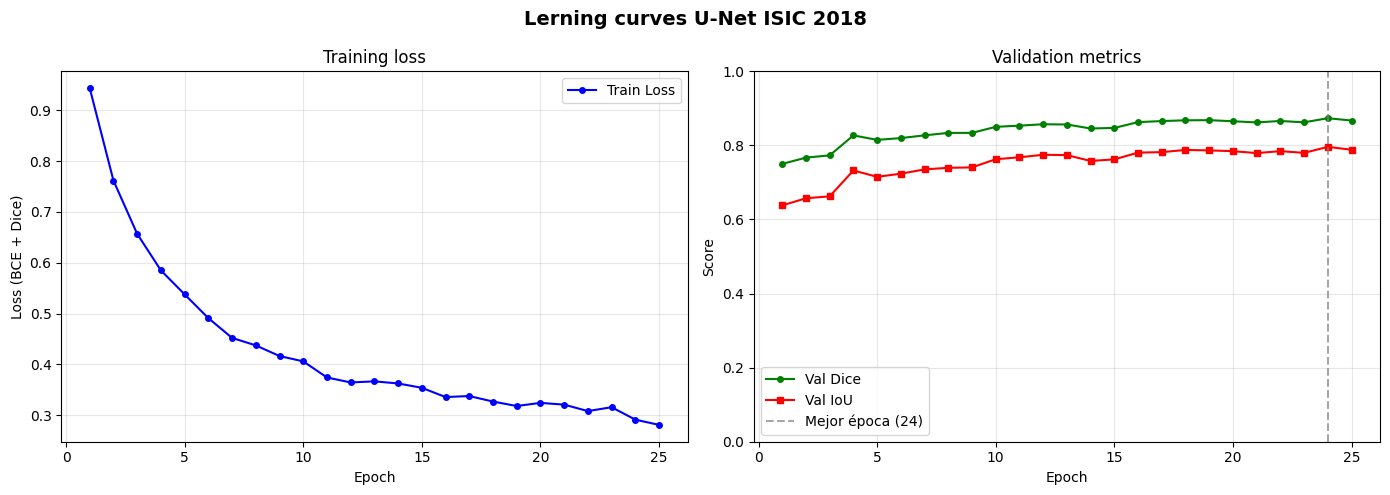

Figure saved: learning_curves.png


In [11]:
# ============================================================
# 10. LEARNING CURVES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Lerning curves U-Net ISIC 2018", fontsize=14, fontweight="bold")

# Training loss
axes[0].plot(history["epoch"], history["train_loss"], "b-o", markersize=4, label="Train Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss (BCE + Dice)")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Dice and IoU in validation
axes[1].plot(history["epoch"], history["val_dice"], "g-o", markersize=4, label="Val Dice")
axes[1].plot(history["epoch"], history["val_iou"],  "r-s", markersize=4, label="Val IoU")
best_epoch = history["val_dice"].index(max(history["val_dice"])) + 1
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.7, label=f"Mejor época ({best_epoch})")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Score")
axes[1].set_title("Validation metrics"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: learning_curves.png")


In [12]:
# ============================================================
# 11. EVALUACIÓN FINAL — TEST SET
# ============================================================
model.load_state_dict(torch.load("unet_best.pth", map_location=device, weights_only=True))
model.eval()

test_metrics = {"dice": 0., "iou": 0., "precision": 0., "recall": 0., "specificity": 0.}
all_dice_scores = []  # to calculate std

with torch.no_grad():
    for imgs, masks, _ in test_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        probs = torch.sigmoid(model(imgs))
        preds = (probs > 0.5).float()

        batch = compute_metrics(masks, preds)
        for k in test_metrics:
            test_metrics[k] += batch[k]

        # Dice per image (for std)
        m = masks.view(masks.size(0), -1)
        p = preds.view(preds.size(0), -1)
        eps = 1e-7
        per_img_dice = ((2 * (p * m).sum(1) + eps) /
                        (p.sum(1) + m.sum(1) + eps)).cpu().numpy()
        all_dice_scores.extend(per_img_dice.tolist())

for k in test_metrics:
    test_metrics[k] /= len(test_loader)

dice_std = np.std(all_dice_scores)

#Results table ──────────────────────────────────────
print("=" * 50)
print("  FINAL RESULTS — TEST SET")
print("=" * 50)
print(f"  Dice / F1      : {test_metrics['dice']:.4f}  (±{dice_std:.4f})")
print(f"  IoU / Jaccard  : {test_metrics['iou']:.4f}")
print(f"  Precision      : {test_metrics['precision']:.4f}")
print(f"  Recall (Sens.) : {test_metrics['recall']:.4f}")
print(f"  Specificity    : {test_metrics['specificity']:.4f}")
print("=" * 50)
print(f"  Total test images evaluated: {len(all_dice_scores)}")

# Save in CSV
with open("test_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "value"])
    for k, v in test_metrics.items():
        writer.writerow([k, f"{v:.6f}"])
    writer.writerow(["dice_std", f"{dice_std:.6f}"])
print("Results saved in test_results.csv")


  FINAL RESULTS — TEST SET
  Dice / F1      : 0.8723  (±0.1615)
  IoU / Jaccard  : 0.8005
  Precision      : 0.8967
  Recall (Sens.) : 0.8929
  Specificity    : 0.9706
  Total test images evaluated: 390
Results saved in test_results.csv


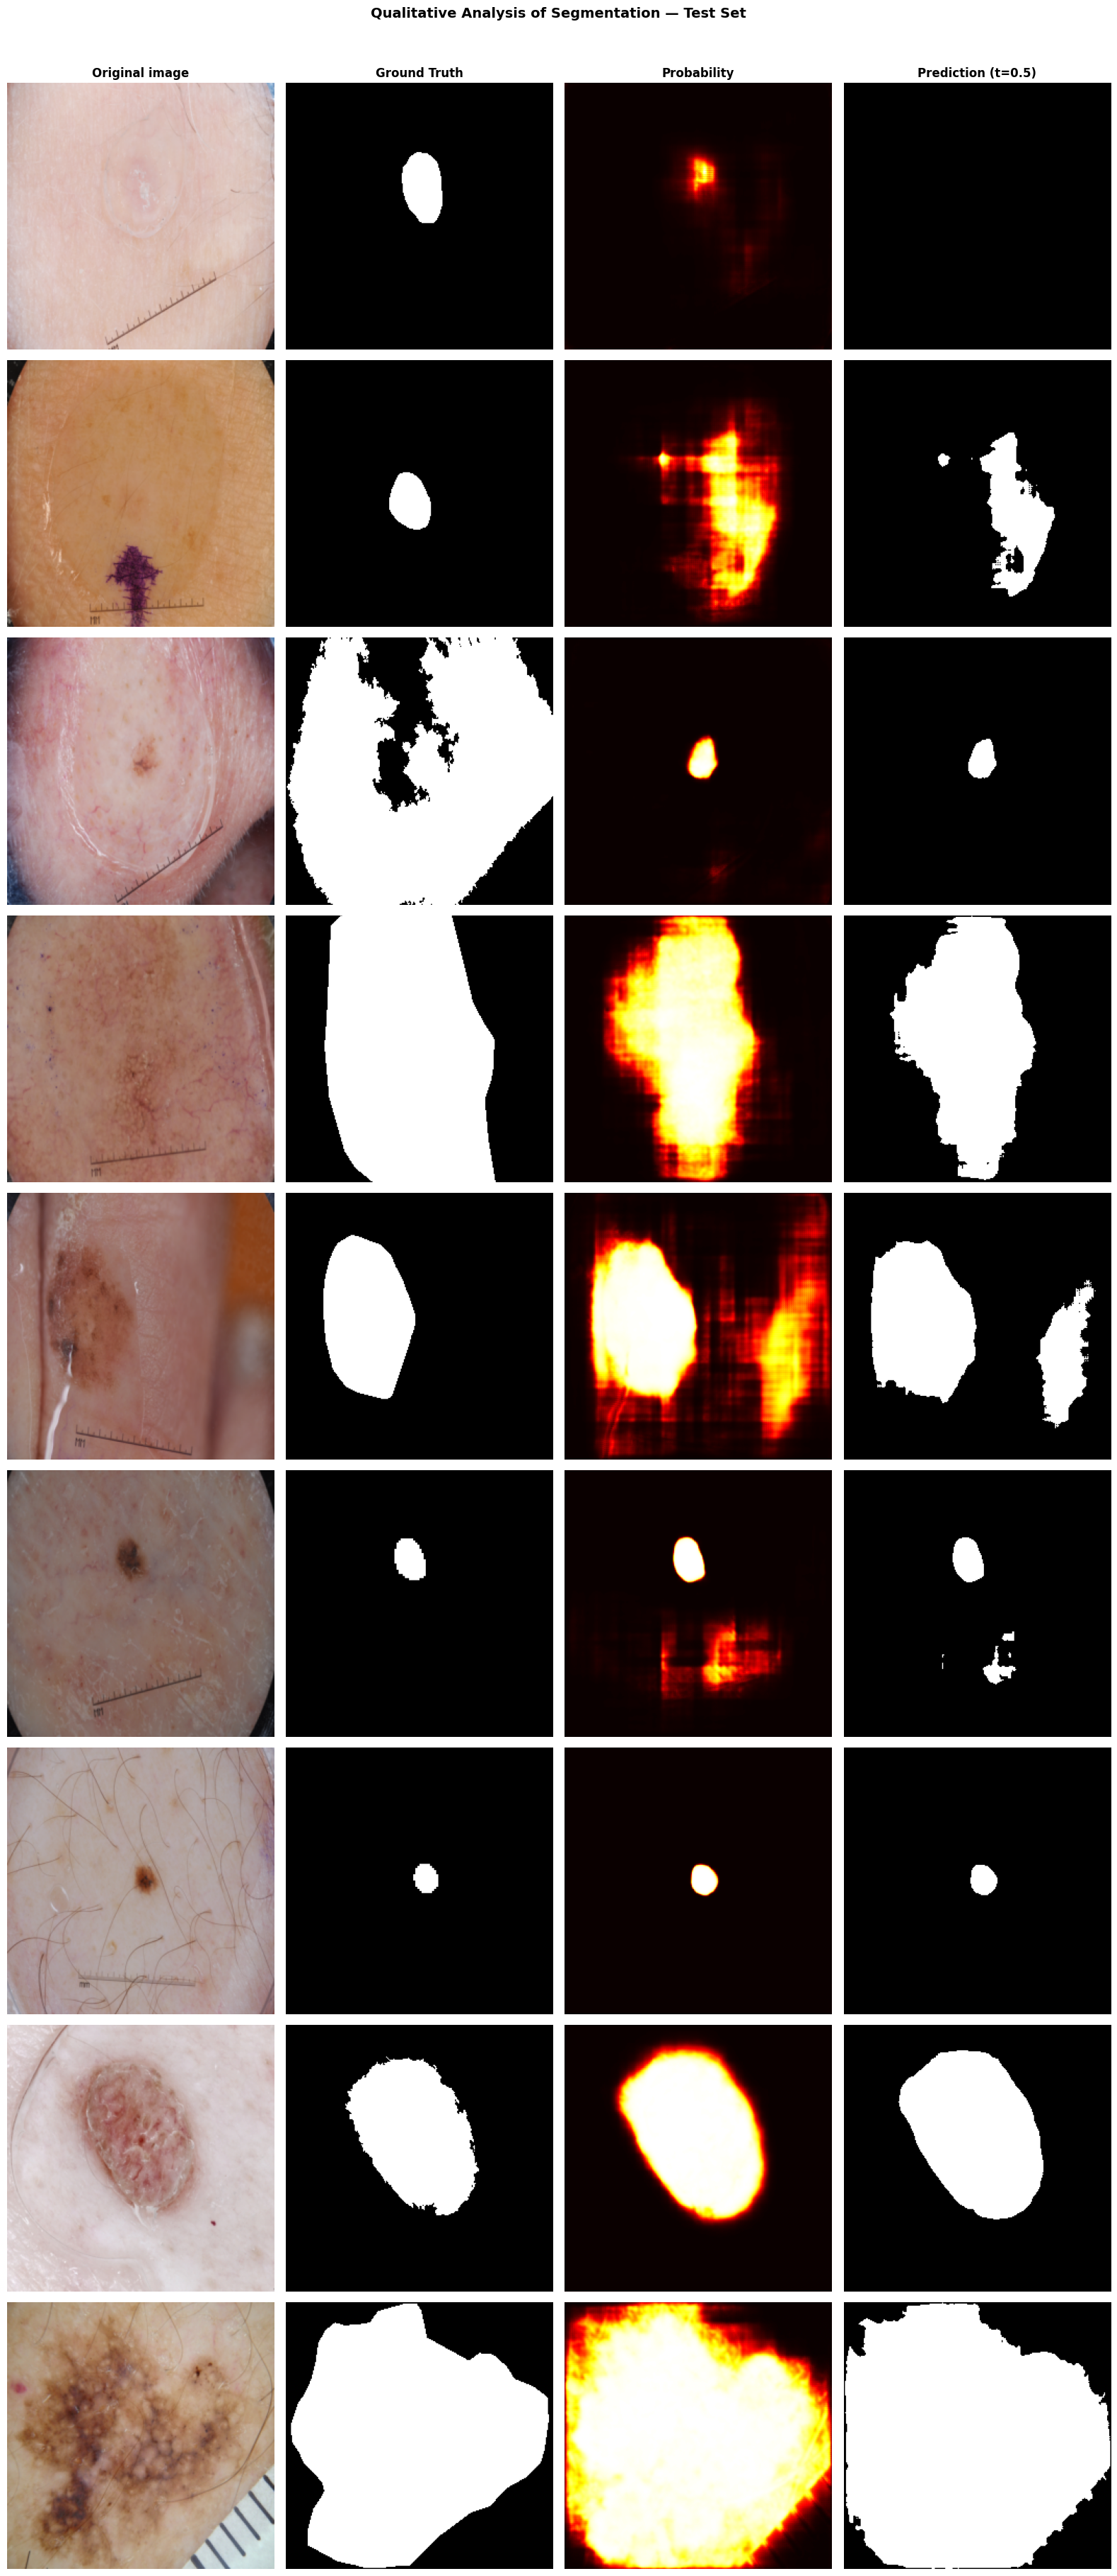

Figure saved: visualizacion_cualitativa.png


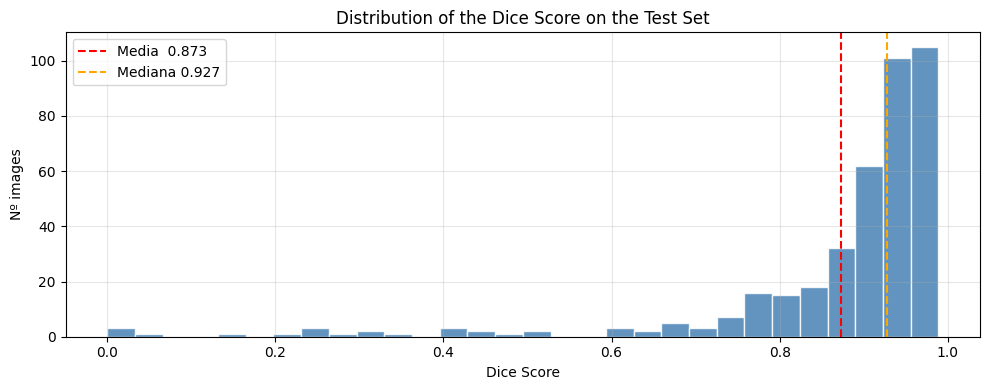

Figure saved: histograma_dice.png


In [13]:
# ============================================================
# 12. QUALITATIVE VISUALIZATION
# ============================================================

# Calculate Dice score per image on the test set ──────────────────
model.eval()
per_image_results = []  #dice, img_tensor, mask_tensor, prob_tensor, fname

with torch.no_grad():
    for imgs, masks, fnames in test_loader:
        imgs_d, masks_d = imgs.to(device), masks.to(device)
        probs_d = torch.sigmoid(model(imgs_d))
        preds_d = (probs_d > 0.5).float()

        m = masks_d.view(masks_d.size(0), -1)
        p = preds_d.view(preds_d.size(0), -1)
        eps = 1e-7
        dice_per = ((2*(p*m).sum(1)+eps) / (p.sum(1)+m.sum(1)+eps)).cpu()

        for i in range(len(fnames)):
            per_image_results.append((
                dice_per[i].item(),
                imgs[i].cpu(),
                masks[i].cpu(),
                probs_d[i].cpu(),
                fnames[i]
            ))

per_image_results.sort(key=lambda x: x[0])

# Select representatives from each group
good  = [r for r in per_image_results if r[0] > 0.90]
mid   = [r for r in per_image_results if 0.75 <= r[0] <= 0.90]
hard  = [r for r in per_image_results if r[0] < 0.75]

#Take 3 from each group or those available
samples = (hard[:3] + mid[:3] + good[:3])
group_labels = (["Dificult"]*min(3,len(hard)) +
                ["Limit"]*min(3,len(mid)) +
                ["Good"]*min(3,len(good)))
group_colors = {"Dificult": "#d62728", "Limit": "#ff7f0e", "Good": "#2ca02c"}

#Denormalize image for visualization ───────────────
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denorm(t):
    return (t * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

# Main figure ──────────────────────────────────────
n = len(samples)
fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
fig.suptitle("Qualitative Analysis of Segmentation — Test Set",
             fontsize=14, fontweight="bold", y=1.01)

col_titles = ["Original image", "Ground Truth", "Probability", "Prediction (t=0.5)"]
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold")

for row, (result, glabel) in enumerate(zip(samples, group_labels)):
    dice_val, img_t, mask_t, prob_t, fname = result
    color = group_colors[glabel]

    pred_t = (prob_t > 0.5).float()
    img_np  = denorm(img_t)
    mask_np = mask_t.squeeze().numpy()
    prob_np = prob_t.squeeze().numpy()
    pred_np = pred_t.squeeze().numpy()

    axes[row, 0].imshow(img_np);         axes[row, 0].axis("off")
    axes[row, 1].imshow(mask_np, cmap="gray"); axes[row, 1].axis("off")
    axes[row, 2].imshow(prob_np, cmap="hot");  axes[row, 2].axis("off")
    axes[row, 3].imshow(pred_np, cmap="gray"); axes[row, 3].axis("off")

    # Etiqueta lateral con grupo y Dice
    axes[row, 0].set_ylabel(f"{glabel}\nDice={dice_val:.3f}",
                             fontsize=10, color=color, fontweight="bold",
                             rotation=0, labelpad=60, va="center")
    for col in range(4):
        for spine in axes[row, col].spines.values():
            spine.set_edgecolor(color); spine.set_linewidth(2)

plt.tight_layout()
plt.savefig("visualizacion_cualitativa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: visualizacion_cualitativa.png")

#Dice Distribution Histogram ───────────────────
all_dices = [r[0] for r in per_image_results]
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_dices, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(np.mean(all_dices),  color="red",    linestyle="--", label=f"Media  {np.mean(all_dices):.3f}")
ax.axvline(np.median(all_dices),color="orange", linestyle="--", label=f"Mediana {np.median(all_dices):.3f}")
ax.set_xlabel("Dice Score"); ax.set_ylabel("Nº images")
ax.set_title("Distribution of the Dice Score on the Test Set")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("histograma_dice.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: histograma_dice.png")


In [14]:
# ============================================================
# 13. FINAL SUMMARY OF THE EXPERIMENT
# ============================================================
print("=" * 60)
print("  SUMMARY OF THE EXPERIMENT — TFG Dermoscopic Segmentation")
print("=" * 60)
print(f"  Dataset        : ISIC 2018 Task 1")
print(f"  Architecture   : U-Net (in-house implementation, PyTorch)")
print(f"  Parameters     : {n_params:,}  ({n_params/1e6:.1f}M)")
print(f"  Resolution     : {IMG_SIZE}×{IMG_SIZE} px")
print(f"  Batch size     : {BATCH_SIZE}")
print(f"  Epochs         : {NUM_EPOCHS}")
print(f"  Initial LR     : {LR}")
print(f"  Loss           : BCE + Dice Loss")
print(f"  Optimizer      : Adam  (weight_decay=1e-5)")
print(f"  Scheduler      : ReduceLROnPlateau (patience=3, factor=0.5)")
print(f"  Split          : 70 / 15 / 15  (train/val/test)")
print()
print("  ── TEST SET RESULTS ──────────────────────────────")
print(f"  Dice / F1      : {test_metrics['dice']:.4f}  (±{dice_std:.4f})")
print(f"  IoU / Jaccard  : {test_metrics['iou']:.4f}")
print(f"  Precision      : {test_metrics['precision']:.4f}")
print(f"  Recall         : {test_metrics['recall']:.4f}")
print(f"  Specificity    : {test_metrics['specificity']:.4f}")
print("=" * 60)


  SUMMARY OF THE EXPERIMENT — TFG Dermoscopic Segmentation
  Dataset        : ISIC 2018 Task 1
  Architecture   : U-Net (in-house implementation, PyTorch)
  Parameters     : 31,037,633  (31.0M)
  Resolution     : 256×256 px
  Batch size     : 8
  Epochs         : 25
  Initial LR     : 0.0001
  Loss           : BCE + Dice Loss
  Optimizer      : Adam  (weight_decay=1e-5)
  Scheduler      : ReduceLROnPlateau (patience=3, factor=0.5)
  Split          : 70 / 15 / 15  (train/val/test)

  ── TEST SET RESULTS ──────────────────────────────
  Dice / F1      : 0.8723  (±0.1615)
  IoU / Jaccard  : 0.8005
  Precision      : 0.8967
  Recall         : 0.8929
  Specificity    : 0.9706


In [15]:
# ============================================================
# 14. DESCARGAR TODOS LOS ARCHIVOS IMPORTANTES
# ============================================================
import os
import shutil
from IPython.display import FileLink, display

# Crear carpeta de resultados
output_folder = "TFG_19_Marz"
os.makedirs(output_folder, exist_ok=True)

# Lista de archivos a incluir
files_to_save = [
    "unet_best.pth",
    "training_history.csv",
    "test_results.csv",
    "learning_curves.png",
    "visualizacion_cualitativa.png",
    "histograma_dice.png",
]

# Copiar cada archivo a la carpeta
for f in files_to_save:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(output_folder, f))
        print(f"✅ {f} copiado")
    else:
        print(f"⚠️  {f} NO encontrado")

# Comprimir todo en un ZIP
zip_name = "TFG_19_Marz"
shutil.make_archive(zip_name, "zip", output_folder)
print(f"\n📦 ZIP creado: {zip_name}.zip")

# Mostrar enlace de descarga
display(FileLink(f"{zip_name}.zip"))
print("\n👆 Haz clic en el enlace de arriba para descargar el ZIP")

✅ unet_best.pth copiado
✅ training_history.csv copiado
✅ test_results.csv copiado
✅ learning_curves.png copiado
✅ visualizacion_cualitativa.png copiado
✅ histograma_dice.png copiado

📦 ZIP creado: TFG_19_Marz.zip


/workspace/TFG_19_Marz.zip


👆 Haz clic en el enlace de arriba para descargar el ZIP
